In [7]:
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader # for image + table+ text kind of. data use --> unstructured.io libraries
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_chroma import Chroma
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel
load_dotenv()

True

In [2]:
# 1 load the pdf files
pdf_loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = pdf_loader.load()

In [3]:
# 2 . split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = text_splitter.split_documents(raw_docs)
print(len(chunks))

51


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
    # persist_directory="../chroma_db". # this is optional for this run
)

vectorstore.add_documents(chunks)

# retrieval strategy
retriever = vectorstore.as_retriever( search_kwargs={"k": 4})

In [44]:
class AgenticRAGState(MessagesState):
    query: str
    retrieved_docs: list[Document] | None
    context: str | None
    generation: str
    needs_retrieval: bool
llm = ChatOpenAI(model="gpt-4o-mini")

In [8]:
class RouteDecision(BaseModel):
    needs_retrieval: bool

In [ ]:
def route_question(state: AgenticRAGState):
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})
    return {"needs_retrieval": decision.needs_retrieval}


In [36]:
route_question(AgenticRAGState(query="What is the impact of oil price shocks on the economy?"))

{'needs_retrieval': False}

In [17]:
# llm.invoke("who is prime minister of Maharashtra")

In [18]:
def retrieve(state: AgenticRAGState):
    docs = retriever.invoke(state['query'])
    if docs:
        context = "\n\n".join([doc.page_content for doc in docs])
    return {"retrieved_docs": docs, "context": context}

In [48]:
def generate(state: AgenticRAGState):
    query = state['query']
    context = state['context']
    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        chain = prompt_template | llm | StrOutputParser()
        response = chain.invoke({"query": query, "context": context})
        return {"generation": response}
    else:
        print('inside else part')
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        chain = prompt_template | llm | StrOutputParser()
        response = chain.invoke({"query": query, "context": None})
        return {"generation": response}


In [49]:
generate(AgenticRAGState(query="Who is PM of India?", context=None))

inside else part


{'generation': 'As of my last knowledge update in October 2023, the Prime Minister of India is Narendra Modi. He has been in office since May 2014. Please verify with current sources for the most up-to-date information.'}

In [50]:
from typing import Literal

In [51]:
def route_after_classification(state: AgenticRAGState) -> Literal["retrieve", "generate"]:
    return "retrieve" if state['needs_retrieval'] else "generate"


In [52]:
graph_builder = StateGraph(AgenticRAGState)
graph_builder.add_node("needs_retrieval", route_question)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "needs_retrieval")
graph_builder.add_conditional_edges("needs_retrieval", route_after_classification)
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [53]:
graph = graph_builder.compile()

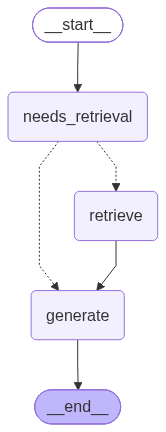

In [54]:
graph

In [59]:
# Query 1: domain-specific (should trigger retrieval)
domain_query = "What does the report say about EV adoption trajectories and oil demand displacement?"

result_domain = graph.invoke({"query": domain_query, "messages": []})

In [60]:
result_domain

{'messages': [],
 'query': 'What does the report say about EV adoption trajectories and oil demand displacement?',
 'retrieved_docs': [Document(id='9c73843f-852d-49be-8485-7aa27d04bfc3', metadata={'creator': '(unspecified)', 'trapped': '/False', 'total_pages': 15, 'title': '(anonymous)', 'moddate': '2026-04-18T21:49:03+05:00', 'page': 7, 'source': '../documents/evs_oil_price_shock.pdf', 'keywords': '', 'creationdate': '2026-04-18T21:49:03+05:00', 'page_label': '8', 'subject': '(unspecified)', 'author': '(anonymous)', 'producer': 'ReportLab PDF Library - (opensource)'}, page_content='Will EVs Dampen the Oil Price Shock?\nVersion 1.0\nResearch Report — For Educational and RAG Pipeline Use\nPage 8\n4. EV Adoption Trajectories and Oil Demand Displacement\n Projecting oil demand displacement from EV adoption requires integrating three distinct\nanalytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing\nICE fleet, and the average annual mileage and fuel 

In [61]:
general_query = "What is the capital of India?"
result_general = graph.invoke({"query": general_query, "messages": [], "context": None})

inside else part


In [62]:
result_general

{'messages': [],
 'query': 'What is the capital of India?',
 'context': None,
 'generation': 'The capital of India is New Delhi.',
 'needs_retrieval': False}